In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Concatenate, Embedding
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LeakyReLU, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
import datetime
import io
import os
import json


In [40]:

# --- 1. Load and Preprocess Data ---
(x_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5


In [41]:

# --- 2. Define Model Constants and Hyperparameters ---
IMG_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
LATENT_DIM = 128
EPOCHS = 150
BATCH_SIZE = 128
CRITIC_STEPS = 3
GP_WEIGHT = 10.0
LEARNING_RATE = 0.0001
BETA_1 = 0.0
BETA_2 = 0.9



In [42]:
# --- 3. Build Critic and Generator Models ---
def build_critic():
    """Builds the Critic model (modified Discriminator for WGAN)."""
    img_input = Input(shape=IMG_SHAPE, name="critic_img_input")
    label_input = Input(shape=(1,), name="critic_label_input")
    label_embedding = Embedding(NUM_CLASSES, 50)(label_input)
    label_embedding = Dense(IMG_SHAPE[0] * IMG_SHAPE[1])(label_embedding)
    label_embedding = Reshape((IMG_SHAPE[0], IMG_SHAPE[1], 1))(label_embedding)
    concatenated_input = Concatenate()([img_input, label_embedding])
    x = Conv2D(64, kernel_size=4, strides=2, padding='same')(concatenated_input)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(512, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Flatten()(x)
    x = Dense(1)(x) # No sigmoid activation
    critic = Model([img_input, label_input], x, name="critic")
    return critic

def build_generator():
    """Builds the Generator model."""
    noise_input = Input(shape=(LATENT_DIM,), name="gen_noise_input")
    label_input = Input(shape=(1,), name="gen_label_input")
    label_embedding = Embedding(NUM_CLASSES, 50)(label_input)
    label_embedding = Dense(4 * 4)(label_embedding)
    label_embedding = Reshape((4, 4, 1))(label_embedding)
    noise = Dense(256 * 4 * 4, activation='relu')(noise_input)
    noise = Reshape((4, 4, 256))(noise)
    concatenated_input = Concatenate()([noise, label_embedding])
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(concatenated_input)
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = Conv2D(3, kernel_size=5, padding='same', activation='tanh')(x)
    generator = Model([noise_input, label_input], x, name="generator")
    return generator



In [43]:
# --- 4. Create the WGAN-GP Model Class (with advanced logging) ---
class WGAN(tf.keras.Model):
    def __init__(self, critic, generator, latent_dim, critic_extra_steps=5, gp_weight=10.0):
        super().__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.c_extra_steps = critic_extra_steps
        self.gp_weight = gp_weight
        

    def compile(self, c_optimizer, g_optimizer, file_writer):
        super().compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.file_writer = file_writer
        self.c_loss_metric = tf.keras.metrics.Mean(name="c_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")
        self.w_dist_metric = tf.keras.metrics.Mean(name="w_dist")
        self.gp_metric = tf.keras.metrics.Mean(name="gp")

    @property
    def metrics(self):
        return [self.c_loss_metric, self.g_loss_metric, self.w_dist_metric, self.gp_metric]

    def gradient_penalty(self, batch_size, real_images, fake_images, labels):
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff
        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.critic([interpolated, labels], training=True)
        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    @tf.function
    def train_step(self, data):
        real_images, labels = data
        batch_size = tf.shape(real_images)[0]

        

        for i in range(self.c_extra_steps):
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_images = self.generator([random_latent_vectors, labels], training=True)
                real_output = self.critic([real_images, labels], training=True)
                fake_output = self.critic([fake_images, labels], training=True)
                w_dist = tf.reduce_mean(real_output) - tf.reduce_mean(fake_output)
                gp = self.gradient_penalty(batch_size, real_images, fake_images, labels)
                c_loss = -w_dist + gp * self.gp_weight
            c_gradient = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(c_gradient, self.critic.trainable_variables))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            generated_images = self.generator([random_latent_vectors, labels], training=True)
            gen_img_output = self.critic([generated_images, labels], training=True)
            g_loss = -tf.reduce_mean(gen_img_output)

        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(gen_gradient, self.generator.trainable_variables))

        self.c_loss_metric.update_state(c_loss)
        self.g_loss_metric.update_state(g_loss)
        self.w_dist_metric.update_state(w_dist)
        self.gp_metric.update_state(gp)
        return {m.name: m.result() for m in self.metrics}

    def save_models(self, save_dir):
        """Save the generator, critic, and training hyperparameters."""
        os.makedirs(save_dir, exist_ok=True)

        generator_path = os.path.join(save_dir, "generator.keras")
        critic_path = os.path.join(save_dir, "critic.keras")
        self.generator.save(generator_path)
        self.critic.save(critic_path)
        print(f"Generator model saved to {generator_path}")
        print(f"Critic model saved to {critic_path}")

        hparams = {
            "latent_dim": self.latent_dim,
            "critic_extra_steps": self.c_extra_steps,
            "gp_weight": self.gp_weight
        }
        hparams_path = os.path.join(save_dir, "hparams.json")
        with open(hparams_path, "w") as f:
            json.dump(hparams, f)
        print(f"Hyperparameters saved to {hparams_path}")

# Add standalone loading function
def load_wgan_models(save_dir):
    """Load WGAN models from saved directory."""
    import json
    import os

    #Loading hyperparameters
    hparams_path = os.path.join(save_dir, 'hparams.json')
    with open(hparams_path, 'r') as f:
        hparams = json.load(f)

    #loading models
    generator_path = os.path.join(save_dir, 'generator.keras')
    critic_path = os.path.join(save_dir, 'critic.keras')

    generator = tf.keras.models.load_model(generator_path)
    critic = tf.keras.models.load_model(critic_path)

    print(f"Loaded generator from {generator_path}")
    print(f"Loaded critic from {critic_path}")

    #Create WGAN instance
    wgan = WGAN(
        critic=critic,
        generator=generator,
        latent_dim=hparams['latent_dim'],
        critic_extra_steps=hparams['critic_extra_steps'],
        gp_weight=hparams['gp_weight']
    )
    return wgan, hparams


In [44]:
# --- 5. Implement Image Sampler Callback with TensorBoard Logging ---
class ImageSampler(tf.keras.callbacks.Callback):
    def __init__(self, num_img=10, latent_dim=128, file_writer=None):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.file_writer = file_writer

    def on_epoch_end(self, epoch, logs=None):
        if epoch > 0 and epoch % 5 == 0:
            noise = tf.random.normal(shape=(self.num_img, self.latent_dim))
            labels = tf.constant(np.arange(0, self.num_img).reshape(-1, 1))
            generated_images = self.model.generator.predict([noise, labels], verbose=0)
            generated_images = (generated_images + 1) / 2.0

            # Log the generated images to TensorBoard
            if self.file_writer:
                with self.file_writer.as_default():
                    tf.summary.image("Generated Images", generated_images, max_outputs=self.num_img, step=epoch)



In [45]:
# --- 6. Train the Model with TensorBoard Callback ---
# Set up the log directory and file writer
log_dir = "logs/wgan/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
MODEL_SAVE_DIR = "models/wgan/"
TEST_SAVE_DIR = "models/wgan_test_verification/"
file_writer = tf.summary.create_file_writer(log_dir)

# Log hyperparameters as text
with file_writer.as_default():
    hparams = {
        "latent_dim": LATENT_DIM, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
        "critic_steps": CRITIC_STEPS, "gp_weight": GP_WEIGHT, "learning_rate": LEARNING_RATE,
        "beta_1": BETA_1, "beta_2": BETA_2
    }
    tf.summary.text("hyperparameters", tf.convert_to_tensor(
        [f'| {key} | {value} |' for key, value in hparams.items()]
    ), step=0)

critic = build_critic()
generator = build_generator()
wgan = WGAN(critic=critic, generator=generator, latent_dim=LATENT_DIM, critic_extra_steps=CRITIC_STEPS, gp_weight=GP_WEIGHT)

wgan.compile(
    c_optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1, beta_2=BETA_2),
    g_optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1, beta_2=BETA_2),
    file_writer=file_writer
)

# Set up the callbacks
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
sampler_callback = ImageSampler(latent_dim=LATENT_DIM, file_writer=file_writer)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)

#Smoke test for checking the logging and other things
#history = wgan.fit(train_dataset, epochs=EPOCHS, callbacks=[sampler_callback, tensorboard_callback])



2026-01-28 16:11:13.427213: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 614400000 exceeds 10% of free system memory.


In [11]:
# #model saving on kaggle for local download
# import shutil
# import os

# # Define the folder where the model will live
# KAGGLE_MODEL_PATH = '/kaggle/working/wgan_final'

# print("--- Saving Final Model for Local Download ---")
# # This uses the save_models function you defined in Cell 5
# wgan.save_models(KAGGLE_MODEL_PATH)

# # Zip the folder so you can download it as one file from the Kaggle sidebar
# shutil.make_archive("wgan_local_bundle", 'zip', KAGGLE_MODEL_PATH)

# print("\n✅ DONE! Download 'wgan_local_bundle.zip' from the Output files on the right.")

In [ ]:
# #--- 7. Launch TensorBoard ---
# #This cell is for your LOCAL notebook. It points to the directory where you downloaded the logs.
# %reload_ext tensorboard
# %tensorboard --logdir /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/kaggle_outputs/output_wgan_train10/logs/wgan

Reusing TensorBoard on port 6007 (pid 9380), started 8:41:16 ago. (Use '!kill 9380' to kill it.)

In [52]:
# Genearting synthetic images from the saved model

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def generate_synthetic_data(model_path, num_samples=5000, batch_size=64):
    """Generate synthetic data from the saved WGAN model."""

    #load the trained model
    wgan, hparams = load_wgan_models(model_path)

    synthetic_images = []
    synthetic_labels = []
    
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        current_batch_size = min(batch_size, num_samples - batch_idx * batch_size)
        
        #generate random noise and random class labels from CIFAR-10 classes
        noise = tf.random.normal(shape=(current_batch_size, hparams['latent_dim']))
        # Randomly select class indices (0-9)
        label_indices = tf.random.uniform(shape=(current_batch_size, 1), minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

        #Generate images 
        generated_images = wgan.generator([noise, label_indices], training=False)

        synthetic_images.append(generated_images.numpy())
        # Store label indices directly (0-9)
        synthetic_labels.append(label_indices.numpy().flatten())

        if (batch_idx + 1) % 10 == 0:
            print(f"Generated batch {batch_idx + 1}/{num_batches}")

    #concatenate all batches
    synthetic_images = np.concatenate(synthetic_images, axis=0)
    synthetic_labels = np.concatenate(synthetic_labels, axis=0)

    print(f"Generated {synthetic_images.shape[0]} synthetic images.")
    return synthetic_images, synthetic_labels

# Generate synthetic images using the trained model from Kaggle
model_path = "/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/wgan_local_bundle_train10/wgan_local_bundle"
output_dir = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Delete existing synthetic images if they exist
existing_images = os.path.join(output_dir, 'synthetic_images.npy')
existing_labels = os.path.join(output_dir, 'synthetic_labels.npy')
if os.path.exists(existing_images):
    os.remove(existing_images)
    print(f"Deleted existing {existing_images}")
if os.path.exists(existing_labels):
    os.remove(existing_labels)
    print(f"Deleted existing {existing_labels}")

# Generate new synthetic data
synthetic_images, synthetic_labels = generate_synthetic_data(model_path, num_samples=50000)

# Save the generated data
np.save(os.path.join(output_dir, 'synthetic_images.npy'), synthetic_images)
np.save(os.path.join(output_dir, 'synthetic_labels.npy'), synthetic_labels)
print(f"Synthetic data saved to {output_dir}!")

Deleted existing /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5/synthetic_images.npy
Deleted existing /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5/synthetic_labels.npy
Loaded generator from /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/wgan_local_bundle_train10/wgan_local_bundle/generator.keras
Loaded critic from /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/wgan_local_bundle_train10/wgan_local_bundle/critic.keras
Generated batch 10/782
Generated batch 20/782
Generated batch 30/782
Generated batch 40/782
Generated batch 50/782
Generated batch 60/782
Generated batch 70/782
Generated batch 80/782
Generated batch 90/782
Generated batch 100/782
Generated batch 110/782
Generated batch 120/782
Generated batch 130/782
Generated batch 140/782
Generated batch

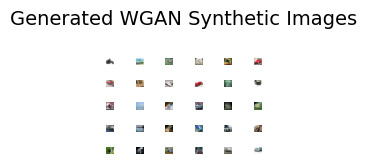

In [53]:
# --- Display 30 generated images as a grid ---
# Load from the saved data directory
data_dir = "/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train10"
imgs = np.load(os.path.join(data_dir, "synthetic_images.npy"))[:30]
labels = np.load(os.path.join(data_dir, "synthetic_labels.npy"))[:30]

# If images are still in [-1, 1], rescale for display
imgs_display = (imgs + 1) / 2.0

cols = 6
rows = 5
# Calculate figure size based on native 32x32 pixels per image (at 100 DPI)
dpi = 100
figsize_width = (cols * 32) / dpi
figsize_height = (rows * 32) / dpi
plt.figure(figsize=(figsize_width, figsize_height), dpi=dpi)
for i, img in enumerate(imgs_display):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Generated WGAN Synthetic Images", fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# ## Loading all the datasets 

# SYNTHETIC_DATA_DIR = '//home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5' 

# # Load the original CIFAR-10 data (training and testing sets)
# (x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.cifar10.load_data()

# # Debug: Check if directory exists
# print(f"Checking directory: {SYNTHETIC_DATA_DIR}")
# print(f"Directory exists: {os.path.exists(SYNTHETIC_DATA_DIR)}")
# if os.path.exists(SYNTHETIC_DATA_DIR):
#     print(f"Files in directory: {os.listdir(SYNTHETIC_DATA_DIR)}")

# # Load your generated synthetic data from the files you downloaded
# try:
#     synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
#     synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))
#     print("--- Datasets Loaded Successfully ---")
# except FileNotFoundError:
#     print(f"--- ERROR: Could not find dataset files in '{SYNTHETIC_DATA_DIR}' ---")
#     print("Please make sure 'synthetic_images.npy' and 'synthetic_labels.npy' are in the correct folder.")
#     # Exit if files are not found
#     exit()

# print(f"Original training images shape: {x_train_orig.shape}")
# print(f"Synthetic training images shape: {synthetic_images.shape}")
# print(f"Test images shape: {x_test_orig.shape}")
# print("-" * 25)

Checking directory: //home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5
Directory exists: True
Files in directory: ['synthetic_labels.npy', 'synthetic_images.npy']
--- Datasets Loaded Successfully ---
Original training images shape: (50000, 32, 32, 3)
Synthetic training images shape: (5000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)
-------------------------


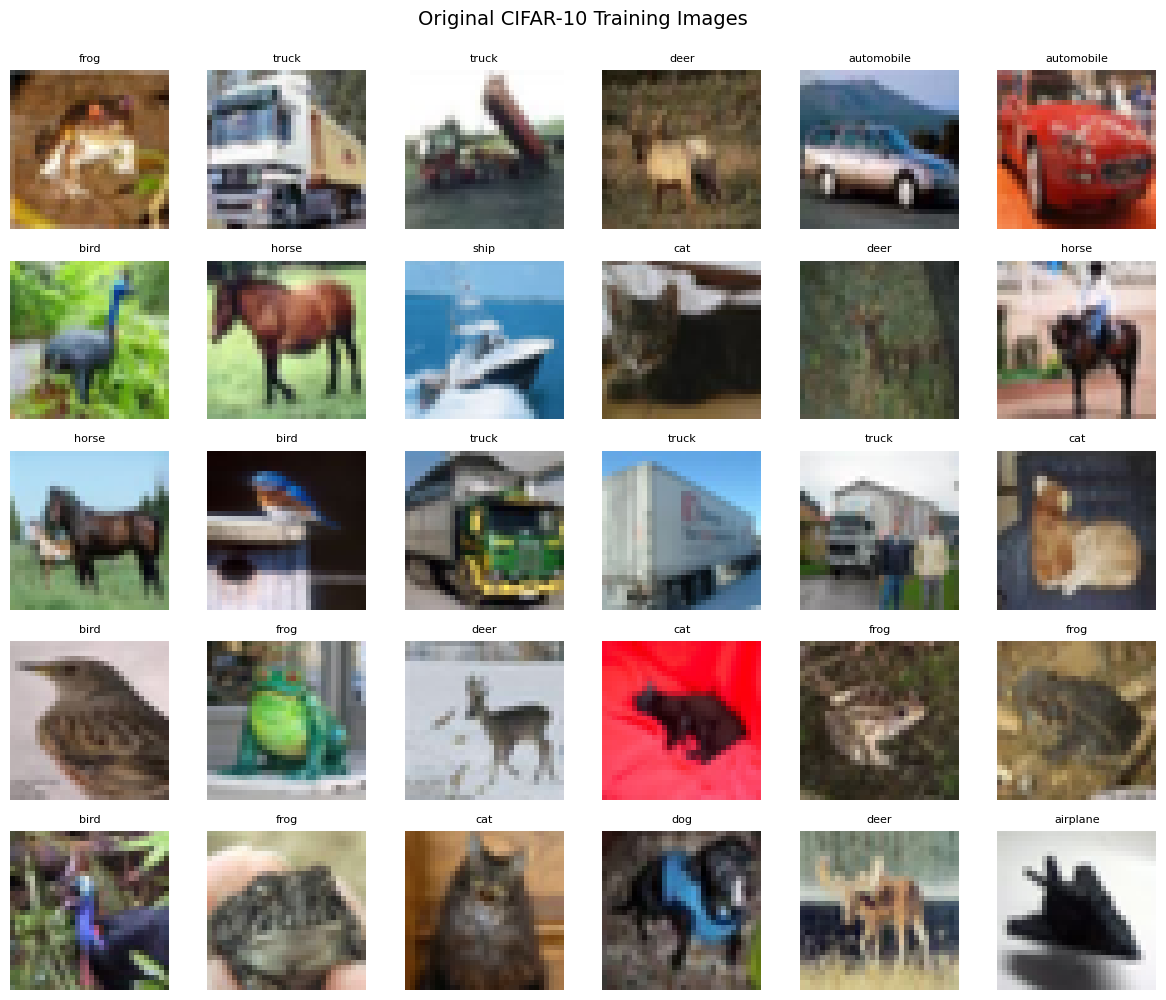

In [ ]:
# # --- Display 30 original CIFAR-10 training images as a grid ---
# # Load original CIFAR-10 training data
# (x_train_orig, y_train_orig), _ = tf.keras.datasets.cifar10.load_data()

# # CIFAR-10 class names
# class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# # Normalize from [0, 255] to [0, 1] for display
# x_train_orig_display = x_train_orig.astype('float32') / 255.0

# # Display first 30 images with labels
# imgs_orig = x_train_orig_display[:30]
# labels_orig = y_train_orig[:30].flatten()

# cols = 6
# rows = 5
# plt.figure(figsize=(12, 10))
# for i, img in enumerate(imgs_orig):
#     plt.subplot(rows, cols, i + 1)
#     plt.imshow(img)
#     plt.title(f"{class_names[labels_orig[i]]}", fontsize=8)
#     plt.axis("off")
# plt.suptitle("Original CIFAR-10 Training Images", fontsize=14, y=0.995)
# plt.tight_layout()
# plt.show()


In [ ]:
# from tensorflow.keras.utils import to_categorical
# import numpy as np

# print("--- Preprocessing Data ---")
# # Normalize Real Data
# x_train_orig_norm = x_train_orig.astype('float32') / 255.0
# x_test_orig_norm = x_test_orig.astype('float32') / 255.0

# # Rescale GAN Data
# x_synthetic_norm = (synthetic_images + 1.0) / 2.0

# # One-hot encode (assuming labels are already integers)
# y_train_orig_cat = to_categorical(y_train_orig, 10)
# y_test_orig_cat = to_categorical(y_test_orig, 10)
# y_synthetic_cat = to_categorical(synthetic_labels, 10)

# # Create Augmented Set
# x_augmented = np.concatenate([x_train_orig_norm, x_synthetic_norm], axis=0)
# y_augmented = np.concatenate([y_train_orig_cat, y_synthetic_cat], axis=0)

# print(f"Check shapes: Augmented X: {x_augmented.shape}, Augmented Y: {y_augmented.shape}")

--- Preprocessing Data ---
Check shapes: Augmented X: (55000, 32, 32, 3), Augmented Y: (55000, 10)


In [ ]:

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# def build_mobilenet_v2():
#     """Returns a compiled MobileNetV2 model with frozen base."""
#     base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
#     base_model.trainable = False # Freeze by default for Phase 1
    
#     model = Sequential([
#         base_model,
#         GlobalAveragePooling2D(),
#         Dense(256, activation='relu'),
#         Dropout(0.3),
#         Dense(10, activation='softmax')
#     ])
    
#     model.compile(optimizer=Adam(learning_rate=1e-3), 
#                   loss='categorical_crossentropy', metrics=['accuracy'])
#     return model, base_model

In [ ]:
# # --- Diagnostic Check ---
# print(f"Samples in Training Set: {len(x_augmented)}")
# if len(x_augmented) == 0:
#     print("CRITICAL ERROR: No data found in x_augmented!")

# # Test building the model
# classifier_test, base_test = build_mobilenet_v2()
# classifier_test.summary()

# print("\nIf 'Trainable params' is > 0 and 'Samples' > 0, the 0.0s error was likely a display lag.")

Samples in Training Set: 55000


/tmp/ipykernel_12536/3710799430.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


If 'Trainable params' is > 0 and 'Samples' > 0, the 0.0s error was likely a display lag.


In [ ]:
# #loading the cifar10 images and normalizing the pixel values in [0,1] range which is expected by mobilenetv2
# import tensorflow as tf
# from tensorflow.keras.datasets import cifar10
# from tensorflow.keras.utils import to_categorical

# print("--- Loading and Preprocessing CIFAR-10 ---")
# (x_train, y_train), (x_test, y_test) = cifar10.load_data()

# # Normalize pixel values to [0, 1]
# x_train = x_train.astype('float32') / 255.0
# x_test = x_test.astype('float32') / 255.0

# # One-hot encode labels (10 classes)
# y_train_cat = to_categorical(y_train, 10)
# y_test_cat = to_categorical(y_test, 10)

# print(f"Data ready: {x_train.shape[0]} training samples, {x_test.shape[0]} test samples.")

--- Loading and Preprocessing CIFAR-10 ---
Data ready: 50000 training samples, 10000 test samples.


In [ ]:
# #using mobilenetv2 as a multiclass classifier
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

# # 1. Load the pre-trained MobileNetV2 base
# # Base MobileNetV2 configured for 96x96 as loading 32X32 images lead to no useful accuracy when downsampling happens in 32X32 images
# base_model = MobileNetV2(
#     input_shape=(96, 96, 3), 
#     include_top=False, 
#     weights='imagenet'
# )
# base_model.trainable = False  # Freeze for Phase 1

# # 2. Sequential Model with On-the-Fly Resizing
# input_shape = (32, 32, 3)  # CIFAR-10 input shape
# model = Sequential([
#     Input(shape=input_shape),
#     Resizing(96, 96, interpolation="bilinear"), # Upsampling to 96x96
#     base_model,
#     GlobalAveragePooling2D(),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )


# model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# import datetime

# # 1. Setup the Log Directory with a timestamp
# # This ensures that every time you run the cell, you get a new set of curves
# log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# # 2. Define the TensorBoard Callback
# tensorboard_callback = tf.keras.callbacks.TensorBoard(
#     log_dir=log_dir, 
#     histogram_freq=1,  # Record weights/biases distributions every epoch
#     update_freq='epoch'
# )

# # --- PHASE 1: Train the Head (Warm-up) ---
# print(f"\n--- Phase 1: Training the custom head (Logs: {log_dir}) ---")
# model.fit(x_train, y_train_cat, 
#           epochs=5, 
#           batch_size=64, 
#           validation_data=(x_test, y_test_cat),
#           callbacks=[tensorboard_callback]) # Added callback

# # --- PHASE 2: Fine-Tuning (Full model) ---
# print("\n--- Phase 2: Unfreezing base and fine-tuning ---")
# base_model.trainable = True

# # Re-compile with a very low learning rate
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])



# # Train for more epochs to adapt the base weights
# model.fit(x_train, y_train_cat, 
#           epochs=10, 
#           batch_size=64, 
#           validation_data=(x_test, y_test_cat),
#           callbacks=[tensorboard_callback]) # Added callback

In [ ]:
# import os
# import shutil

# # 1. Define names for your folder and the zip file
# model_folder = './finetuned_model_export'
# zip_filename = 'mobilenet_cifar10_results'

# # 2. Create the directory if it doesn't exist
# if not os.path.exists(model_folder):
#     os.makedirs(model_folder)

# # 3. Save the trained model into that folder
# # We use the .keras format as it is the most modern and portable
# model.save(f'{model_folder}/mobilenetv2_cifar10.keras')

# # 4. (Optional) Save your labels or a readme if you want them in the zip
# with open(f'{model_folder}/classes.txt', 'w') as f:
#     f.write('airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck')

# # 5. Zip the entire folder
# # This creates 'mobilenet_cifar10_results.zip' in your /kaggle/working/ directory
# shutil.make_archive(zip_filename, 'zip', model_folder)

# print(f"--- Success! ---")
# print(f"Your model has been zipped into: {zip_filename}.zip")
# print("You can now download it from the 'Output' sidebar in Kaggle.")

In [ ]:
# # --- Load Synthetic Images for MobileNetV2 Finetuning ---
# print("--- Loading Synthetic Data ---")

# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train10'

# # Load the synthetic images
# synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
# synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))
# print("--- Synthetic Data Loaded Successfully ---")

# # Rescale synthetic images from [-1, 1] to [0, 1]
# synthetic_images_norm = (synthetic_images + 1.0) / 2.0

# # One-hot encode labels
# y_synthetic_cat = to_categorical(synthetic_labels, 10)

# print(f"Synthetic images shape: {synthetic_images_norm.shape}")
# print(f"Synthetic labels shape: {y_synthetic_cat.shape}")


In [ ]:
# # --- Build Fresh MobileNetV2 for Synthetic Data Finetuning ---
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

# print("--- Building Fresh MobileNetV2 Model ---")

# # Load the pre-trained MobileNetV2 base (fresh, not previously finetuned)
# # Configured for 96x96 input to match CIFAR-10 finetuning approach
# base_model_synthetic = MobileNetV2(input_shape=(96, 96, 3), 
#                                     include_top=False, 
#                                     weights='imagenet')

# # Initially freeze the base model so we only train the new top layers
# base_model_synthetic.trainable = False 

# # Build the final model with upscaling from 32x32 to 96x96
# input_shape_synthetic = (32, 32, 3)  # Synthetic image input
# model_synthetic = Sequential([
#     Input(shape=input_shape_synthetic),
#     Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
#     base_model_synthetic,
#     GlobalAveragePooling2D(),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')  # Multiclass output for 10 classes
# ])

# model_synthetic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#                         loss='categorical_crossentropy',
#                         metrics=['accuracy'])

# print("--- Model Built Successfully ---")
# model_synthetic.summary()


In [ ]:
# # --- PHASE 1: Train the Head on Synthetic Data (Warm-up) ---
# import datetime

# # Setup the Log Directory with a timestamp
# log_dir_synthetic = "logs/fit_synthetic/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# # Define the TensorBoard Callback
# tensorboard_callback_synthetic = tf.keras.callbacks.TensorBoard(
#     log_dir=log_dir_synthetic, 
#     histogram_freq=1,
#     update_freq='epoch'
# )

# print(f"\n--- Phase 1: Training the custom head with Synthetic Data (Logs: {log_dir_synthetic}) ---")
# history_phase1_synthetic = model_synthetic.fit(
#     synthetic_images_norm, y_synthetic_cat, 
#     epochs=5, 
#     batch_size=64, 
#     validation_split=0.2,
#     callbacks=[tensorboard_callback_synthetic]
# )

# print("--- Phase 1 Complete ---")


In [ ]:
# # --- PHASE 2: Fine-Tuning with Unfrozen Base on Synthetic Data ---
# print("\n--- Phase 2: Unfreezing base and fine-tuning with Synthetic Data ---")

# # Unfreeze the base model
# base_model_synthetic.trainable = True

# # Re-compile with a very low learning rate for fine-tuning
# model_synthetic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#                         loss='categorical_crossentropy',
#                         metrics=['accuracy'])

# # Train for more epochs to adapt the base weights
# history_phase2_synthetic = model_synthetic.fit(
#     synthetic_images_norm, y_synthetic_cat, 
#     epochs=10, 
#     batch_size=64, 
#     validation_split=0.2,
#     callbacks=[tensorboard_callback_synthetic]
# )

# print("--- Phase 2 Complete ---")
# print("--- MobileNetV2 Finetuning with Synthetic Data Complete ---")


In [ ]:
# # --- Save the Finetuned MobileNetV2 Model (Synthetic Data) ---
# import shutil

# print("--- Saving Finetuned MobileNetV2 Model (Synthetic Data) ---")

# # Define names for your folder and the zip file
# model_folder_synthetic = './mobilenetv2_synthetic_export'
# zip_filename_synthetic = 'mobilenetv2_synthetic_results'

# # Create the directory if it doesn't exist
# if not os.path.exists(model_folder_synthetic):
#     os.makedirs(model_folder_synthetic)

# # Save the trained model
# model_synthetic.save(f'{model_folder_synthetic}/mobilenetv2_synthetic.keras')

# # Save your labels
# with open(f'{model_folder_synthetic}/classes.txt', 'w') as f:
#     f.write('airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck')

# # Zip the entire folder
# shutil.make_archive(zip_filename_synthetic, 'zip', model_folder_synthetic)

# print(f"--- Success! ---")
# print(f"Your model has been zipped into: {zip_filename_synthetic}.zip")
# print("You can now download it from the Output files.")


In [ ]:
# import tensorflow as tf
# from tensorflow.keras import datasets, layers, models
# from tensorflow.keras.utils import to_categorical

# # 1. Load CIFAR-10
# (_, _), (x_test, y_test) = datasets.cifar10.load_data()

# # 2. Preprocess: Match the normalization used during your training
# # If your GAN/MobileNet used [-1, 1] normalization:
# x_test = (x_test.astype('float32') - 127.5) / 127.5 

# # 3. One-hot encode the labels (IMPORTANT: match training format)
# y_test = to_categorical(y_test, 10)

# # If your MobileNet expects 224x224 (default size), you might need to resize,
# # but since you trained on 32x32 synthetic images, keep them at 32x32.
# print(f"Test data shape: {x_test.shape}")
# print(f"Test labels shape: {y_test.shape}")

Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


In [ ]:
# # Reconstruct the model architecture and load weights
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

# print("--- Reconstructing Model Architecture ---")

# # Rebuild the exact same architecture used during training (with 96x96 upscaling)
# input_shape_eval = (32, 32, 3)  # Synthetic image input
# base_model_eval = MobileNetV2(input_shape=(96, 96, 3), 
#                                include_top=False, 
#                                weights='imagenet')

# model = Sequential([
#     Input(shape=input_shape_eval),
#     Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
#     base_model_eval,
#     GlobalAveragePooling2D(),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')
# ])

# # Compile the model (same as training)
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# # Load the weights from the saved file
# weights_path = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/mobilenetv2_finetuned_synthetic_96X96/mobilenetv2_synthetic_results/mobilenetv2_synthetic.keras'

# try:
#     # Try to load just the weights
#     model.load_weights(weights_path)
#     print("Model weights loaded successfully. Starting evaluation...")
# except Exception as e:
#     print(f"Error loading weights: {e}")
#     print("Attempting alternative loading method...")
#     # Alternative: load the entire model but use its weights
#     try:
#         temp_model = tf.keras.models.load_model(weights_path, compile=False)
#         model.set_weights(temp_model.get_weights())
#         print("Model loaded successfully using alternative method. Starting evaluation...")
#     except Exception as e2:
#         print(f"Alternative method also failed: {e2}")
#         print("You may need to retrain the model.")

--- Reconstructing Model Architecture ---
Model weights loaded successfully. Starting evaluation...


In [ ]:
# # Run the evaluation
# results = model.evaluate(x_test, y_test, batch_size=64)

# print(f"\n--- Evaluation Results on Original CIFAR-10 ---")
# print(f"Test Loss: {results[0]:.4f}")
# print(f"Test Accuracy: {results[1]*100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 281ms/step - accuracy: 0.2987 - loss: 4.7634

--- Evaluation Results on Original CIFAR-10 ---
Test Loss: 4.7634
Test Accuracy: 29.87%


In [ ]:
# # --- Load CIFAR-10 Test Data ---
# import tensorflow as tf
# from tensorflow.keras import datasets
# from tensorflow.keras.utils import to_categorical

# print("--- Loading CIFAR-10 Test Data ---")

# # Load CIFAR-10
# (_, _), (x_test_cifar, y_test_cifar) = datasets.cifar10.load_data()

# # Normalize to [0, 1] range (this is what MobileNetV2 expects)
# x_test_cifar = x_test_cifar.astype('float32') / 255.0

# # One-hot encode labels
# y_test_cifar = to_categorical(y_test_cifar, 10)

# print(f"CIFAR-10 Test data shape: {x_test_cifar.shape}")
# print(f"CIFAR-10 Test labels shape: {y_test_cifar.shape}")


--- Loading CIFAR-10 Test Data ---
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 10)


In [ ]:
# # --- Load the CIFAR-10 Finetuned MobileNetV2 Model ---
# import tensorflow as tf
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

# print("--- Loading CIFAR-10 Finetuned MobileNetV2 Model ---")

# model_cifar_path = "/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/mobilenetv2_finetuned_cifar10_96X96/mobilenet_cifar10_results/mobilenetv2_cifar10.keras"

# # Rebuild the exact same architecture used during training (with 96x96 upscaling)
# input_shape_cifar = (32, 32, 3)  # CIFAR-10 input
# base_model_cifar = MobileNetV2(input_shape=(96, 96, 3), 
#                                 include_top=False, 
#                                 weights='imagenet')

# model_cifar = Sequential([
#     Input(shape=input_shape_cifar),
#     Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
#     base_model_cifar,
#     GlobalAveragePooling2D(),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')
# ])

# # Compile the model
# model_cifar.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#                     loss='categorical_crossentropy',
#                     metrics=['accuracy'])

# # Load the weights from the saved file
# try:
#     model_cifar.load_weights(model_cifar_path)
#     print("Model weights loaded successfully!")
# except Exception as e:
#     print(f"Error loading weights: {e}")
#     print("Attempting alternative loading method...")
#     try:
#         temp_model = tf.keras.models.load_model(model_cifar_path, compile=False)
#         model_cifar.set_weights(temp_model.get_weights())
#         print("Model loaded successfully using alternative method!")
#     except Exception as e2:
#         print(f"Alternative method also failed: {e2}")
#         print("You may need to retrain the model.")


--- Loading CIFAR-10 Finetuned MobileNetV2 Model ---
Model weights loaded successfully!


In [ ]:
# # --- Evaluate CIFAR-10 Finetuned Model on CIFAR-10 Test Set ---
# print("\n--- Evaluating CIFAR-10 Finetuned MobileNetV2 on Original CIFAR-10 Test Data ---")

# results_cifar = model_cifar.evaluate(x_test_cifar, y_test_cifar, batch_size=64)

# print(f"\n--- Evaluation Results: CIFAR-10 Finetuned Model on CIFAR-10 ---")
# print(f"Test Loss: {results_cifar[0]:.4f}")
# print(f"Test Accuracy: {results_cifar[1]*100:.2f}%")



--- Evaluating CIFAR-10 Finetuned MobileNetV2 on Original CIFAR-10 Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 286ms/step - accuracy: 0.9235 - loss: 0.2460

--- Evaluation Results: CIFAR-10 Finetuned Model on CIFAR-10 ---
Test Loss: 0.2460
Test Accuracy: 92.35%


In [ ]:
# # --- Create Augmented Dataset 3: 70% CIFAR-10, 30% Synthetic ---
# import numpy as np
# import os
# from tensorflow.keras.datasets import cifar10

# print("--- Creating Augmented Dataset 3: 70% CIFAR-10, 30% Synthetic ---")

# # Load CIFAR-10 training data
# (x_train_cifar, y_train_cifar), _ = cifar10.load_data()

# # Load synthetic images
# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5'
# synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
# synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))

# # Normalize CIFAR-10 to [-1, 1] to match synthetic images
# x_train_cifar_norm = (x_train_cifar.astype('float32') - 127.5) / 127.5

# # Calculate sample sizes: 70% CIFAR-10 (35k), 30% synthetic (15k)
# np.random.seed(42)
# cifar_indices = np.random.choice(len(x_train_cifar_norm), 35000, replace=False)
# synthetic_indices = np.random.choice(len(synthetic_images), 15000, replace=False)

# # Sample the data
# x_cifar_sampled = x_train_cifar_norm[cifar_indices]
# y_cifar_sampled = y_train_cifar[cifar_indices].flatten()

# x_synthetic_sampled = synthetic_images[synthetic_indices]
# y_synthetic_sampled = synthetic_labels[synthetic_indices]

# # Concatenate to create augmented dataset
# x_augmented_70_30 = np.concatenate([x_cifar_sampled, x_synthetic_sampled], axis=0)
# y_augmented_70_30 = np.concatenate([y_cifar_sampled, y_synthetic_sampled], axis=0)

# # Shuffle the augmented dataset
# shuffle_indices = np.random.permutation(len(x_augmented_70_30))
# x_augmented_70_30 = x_augmented_70_30[shuffle_indices]
# y_augmented_70_30 = y_augmented_70_30[shuffle_indices]

# # Save the augmented dataset
# output_dir = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/70_30_cifar_synthetic'
# os.makedirs(output_dir, exist_ok=True)

# np.save(os.path.join(output_dir, 'augmented_images.npy'), x_augmented_70_30)
# np.save(os.path.join(output_dir, 'augmented_labels.npy'), y_augmented_70_30)

# print(f"Augmented dataset saved to {output_dir}")
# print(f"Total samples: {len(x_augmented_70_30)}")
# print(f"CIFAR-10 samples: 35000 (70%)")
# print(f"Synthetic samples: 15000 (30%)")
# print(f"Images shape: {x_augmented_70_30.shape}")
# print(f"Labels shape: {y_augmented_70_30.shape}")

--- Creating Augmented Dataset 3: 70% CIFAR-10, 30% Synthetic ---


Augmented dataset saved to /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/70_30_cifar_synthetic
Total samples: 50000
CIFAR-10 samples: 35000 (70%)
Synthetic samples: 15000 (30%)
Images shape: (50000, 32, 32, 3)
Labels shape: (50000,)


In [ ]:
# # --- Create Augmented Dataset 2: 60% Synthetic, 40% CIFAR-10 ---
# import numpy as np
# import os
# from tensorflow.keras.datasets import cifar10

# print("--- Creating Augmented Dataset 2: 60% Synthetic, 40% CIFAR-10 ---")

# # Load CIFAR-10 training data
# (x_train_cifar, y_train_cifar), _ = cifar10.load_data()

# # Load synthetic images
# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5'
# synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
# synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))

# # Normalize CIFAR-10 to [-1, 1] to match synthetic images
# x_train_cifar_norm = (x_train_cifar.astype('float32') - 127.5) / 127.5

# # Calculate sample sizes: 60% synthetic (30k), 40% CIFAR-10 (20k)
# np.random.seed(42)
# cifar_indices = np.random.choice(len(x_train_cifar_norm), 20000, replace=False)
# synthetic_indices = np.random.choice(len(synthetic_images), 30000, replace=False)

# # Sample the data
# x_cifar_sampled = x_train_cifar_norm[cifar_indices]
# y_cifar_sampled = y_train_cifar[cifar_indices].flatten()

# x_synthetic_sampled = synthetic_images[synthetic_indices]
# y_synthetic_sampled = synthetic_labels[synthetic_indices]

# # Concatenate to create augmented dataset
# x_augmented_60_40 = np.concatenate([x_cifar_sampled, x_synthetic_sampled], axis=0)
# y_augmented_60_40 = np.concatenate([y_cifar_sampled, y_synthetic_sampled], axis=0)

# # Shuffle the augmented dataset
# shuffle_indices = np.random.permutation(len(x_augmented_60_40))
# x_augmented_60_40 = x_augmented_60_40[shuffle_indices]
# y_augmented_60_40 = y_augmented_60_40[shuffle_indices]

# # Save the augmented dataset
# output_dir = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/60_40_synthetic_cifar'
# os.makedirs(output_dir, exist_ok=True)

# np.save(os.path.join(output_dir, 'augmented_images.npy'), x_augmented_60_40)
# np.save(os.path.join(output_dir, 'augmented_labels.npy'), y_augmented_60_40)

# print(f"Augmented dataset saved to {output_dir}")
# print(f"Total samples: {len(x_augmented_60_40)}")
# print(f"CIFAR-10 samples: 20000 (40%)")
# print(f"Synthetic samples: 30000 (60%)")
# print(f"Images shape: {x_augmented_60_40.shape}")
# print(f"Labels shape: {y_augmented_60_40.shape}")

--- Creating Augmented Dataset 2: 60% Synthetic, 40% CIFAR-10 ---
Augmented dataset saved to /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/60_40_synthetic_cifar
Total samples: 50000
CIFAR-10 samples: 20000 (40%)
Synthetic samples: 30000 (60%)
Images shape: (50000, 32, 32, 3)
Labels shape: (50000,)


In [ ]:
# # --- Create Augmented Dataset 1: Equal Distribution (50% CIFAR-10, 50% Synthetic) ---
# import numpy as np
# import os
# from tensorflow.keras.datasets import cifar10

# print("--- Creating Augmented Dataset 1: Equal Distribution ---")

# # Load CIFAR-10 training data
# (x_train_cifar, y_train_cifar), _ = cifar10.load_data()

# # Load synthetic images
# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train5'
# synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
# synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))

# # Normalize CIFAR-10 to [-1, 1] to match synthetic images
# x_train_cifar_norm = (x_train_cifar.astype('float32') - 127.5) / 127.5

# # Randomly sample 25,000 from each dataset
# np.random.seed(42)
# cifar_indices = np.random.choice(len(x_train_cifar_norm), 25000, replace=False)
# synthetic_indices = np.random.choice(len(synthetic_images), 25000, replace=False)

# # Sample the data
# x_cifar_sampled = x_train_cifar_norm[cifar_indices]
# y_cifar_sampled = y_train_cifar[cifar_indices].flatten()

# x_synthetic_sampled = synthetic_images[synthetic_indices]
# y_synthetic_sampled = synthetic_labels[synthetic_indices]

# # Concatenate to create augmented dataset
# x_augmented_equal = np.concatenate([x_cifar_sampled, x_synthetic_sampled], axis=0)
# y_augmented_equal = np.concatenate([y_cifar_sampled, y_synthetic_sampled], axis=0)

# # Shuffle the augmented dataset
# shuffle_indices = np.random.permutation(len(x_augmented_equal))
# x_augmented_equal = x_augmented_equal[shuffle_indices]
# y_augmented_equal = y_augmented_equal[shuffle_indices]

# # Save the augmented dataset
# output_dir = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/equal_dist_cifar_synthetic'
# os.makedirs(output_dir, exist_ok=True)

# np.save(os.path.join(output_dir, 'augmented_images.npy'), x_augmented_equal)
# np.save(os.path.join(output_dir, 'augmented_labels.npy'), y_augmented_equal)

# print(f"Augmented dataset saved to {output_dir}")
# print(f"Total samples: {len(x_augmented_equal)}")
# print(f"CIFAR-10 samples: 25000 (50%)")
# print(f"Synthetic samples: 25000 (50%)")
# print(f"Images shape: {x_augmented_equal.shape}")
# print(f"Labels shape: {y_augmented_equal.shape}")

--- Creating Augmented Dataset 1: Equal Distribution ---
Augmented dataset saved to /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/augmented/equal_dist_cifar_synthetic
Total samples: 50000
CIFAR-10 samples: 25000 (50%)
Synthetic samples: 25000 (50%)
Images shape: (50000, 32, 32, 3)
Labels shape: (50000,)


In [ ]:
# # --- Load Augmented equal Dataset for MobileNetV2 Finetuning ---
# print("--- Loading Synthetic Data ---")

# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss/WGAN_train10'

# # Load the synthetic images
# synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
# synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))
# print("--- Synthetic Data Loaded Successfully ---")

# # Rescale synthetic images from [-1, 1] to [0, 1]
# synthetic_images_norm = (synthetic_images + 1.0) / 2.0

# # One-hot encode labels
# y_synthetic_cat = to_categorical(synthetic_labels, 10)

# print(f"Synthetic images shape: {synthetic_images_norm.shape}")
# print(f"Synthetic labels shape: {y_synthetic_cat.shape}")


In [ ]:
# # --- Build Fresh MobileNetV2 for Augmented equal Dataset  Finetuning ---
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

# print("--- Building Fresh MobileNetV2 Model ---")

# # Load the pre-trained MobileNetV2 base (fresh, not previously finetuned)
# # Configured for 96x96 input to match CIFAR-10 finetuning approach
# base_model_synthetic = MobileNetV2(input_shape=(96, 96, 3), 
#                                     include_top=False, 
#                                     weights='imagenet')

# # Initially freeze the base model so we only train the new top layers
# base_model_synthetic.trainable = False 

# # Build the final model with upscaling from 32x32 to 96x96
# input_shape_synthetic = (32, 32, 3)  # Synthetic image input
# model_synthetic = Sequential([
#     Input(shape=input_shape_synthetic),
#     Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
#     base_model_synthetic,
#     GlobalAveragePooling2D(),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')  # Multiclass output for 10 classes
# ])

# model_synthetic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#                         loss='categorical_crossentropy',
#                         metrics=['accuracy'])

# print("--- Model Built Successfully ---")
# model_synthetic.summary()


In [ ]:
# # --- PHASE 1: Train the Head on Augmented equal Dataset  (Warm-up) ---
# import datetime

# # Setup the Log Directory with a timestamp
# log_dir_synthetic = "logs/fit_synthetic/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# # Define the TensorBoard Callback
# tensorboard_callback_synthetic = tf.keras.callbacks.TensorBoard(
#     log_dir=log_dir_synthetic, 
#     histogram_freq=1,
#     update_freq='epoch'
# )

# print(f"\n--- Phase 1: Training the custom head with Synthetic Data (Logs: {log_dir_synthetic}) ---")
# history_phase1_synthetic = model_synthetic.fit(
#     synthetic_images_norm, y_synthetic_cat, 
#     epochs=5, 
#     batch_size=64, 
#     validation_split=0.2,
#     callbacks=[tensorboard_callback_synthetic]
# )

# print("--- Phase 1 Complete ---")


In [ ]:
# # --- PHASE 2: Fine-Tuning with Unfrozen Base on Augmented equal Dataset ---
# print("\n--- Phase 2: Unfreezing base and fine-tuning with Synthetic Data ---")

# # Unfreeze the base model
# base_model_synthetic.trainable = True

# # Re-compile with a very low learning rate for fine-tuning
# model_synthetic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#                         loss='categorical_crossentropy',
#                         metrics=['accuracy'])

# # Train for more epochs to adapt the base weights
# history_phase2_synthetic = model_synthetic.fit(
#     synthetic_images_norm, y_synthetic_cat, 
#     epochs=10, 
#     batch_size=64, 
#     validation_split=0.2,
#     callbacks=[tensorboard_callback_synthetic]
# )

# print("--- Phase 2 Complete ---")
# print("--- MobileNetV2 Finetuning with Synthetic Data Complete ---")


In [ ]:
# # --- Save the Finetuned MobileNetV2 Model (Synthetic Data) ---
# import shutil

# print("--- Saving Finetuned MobileNetV2 Model (Synthetic Data) ---")

# # Define names for your folder and the zip file
# model_folder_synthetic = './mobilenetv2_synthetic_export'
# zip_filename_synthetic = 'mobilenetv2_synthetic_results'

# # Create the directory if it doesn't exist
# if not os.path.exists(model_folder_synthetic):
#     os.makedirs(model_folder_synthetic)

# # Save the trained model
# model_synthetic.save(f'{model_folder_synthetic}/mobilenetv2_synthetic.keras')

# # Save your labels
# with open(f'{model_folder_synthetic}/classes.txt', 'w') as f:
#     f.write('airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck')

# # Zip the entire folder
# shutil.make_archive(zip_filename_synthetic, 'zip', model_folder_synthetic)

# print(f"--- Success! ---")
# print(f"Your model has been zipped into: {zip_filename_synthetic}.zip")
# print("You can now download it from the Output files.")


In [62]:
# --- Load Test Data, Reconstruct Model, and Evaluate ---
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

print("--- Loading CIFAR-10 Test Data ---")

# Load CIFAR-10
(_, _), (x_test_cifar_eval, y_test_cifar_eval) = datasets.cifar10.load_data()

# Normalize to [0, 1] range
x_test_cifar_eval = x_test_cifar_eval.astype('float32') / 255.0

# One-hot encode labels
y_test_cifar_eval = to_categorical(y_test_cifar_eval, 10)

print(f"CIFAR-10 Test data shape: {x_test_cifar_eval.shape}")
print(f"CIFAR-10 Test labels shape: {y_test_cifar_eval.shape}")

print("\n--- Reconstructing Model Architecture ---")

# Rebuild the exact same architecture used during training (with 96x96 upscaling)
input_shape_eval = (32, 32, 3)  # CIFAR-10 image input
base_model_eval_new = MobileNetV2(input_shape=(96, 96, 3), 
                                   include_top=False, 
                                   weights='imagenet')

model_eval_new = Sequential([
    Input(shape=input_shape_eval),
    Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
    base_model_eval_new,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile the model
model_eval_new.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Load the weights from the saved file
weights_path_eval = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/mobilenet_finetuned_augmented_1/mobilenetv2_synthetic_results/mobilenetv2_synthetic.keras'

try:
    # Try to load just the weights
    model_eval_new.load_weights(weights_path_eval)
    print("Model weights loaded successfully.")
except Exception as e:
    print(f"Error loading weights: {e}")
    print("Attempting alternative loading method...")
    try:
        temp_model = tf.keras.models.load_model(weights_path_eval, compile=False)
        model_eval_new.set_weights(temp_model.get_weights())
        print("Model loaded successfully using alternative method.")
    except Exception as e2:
        print(f"Alternative method also failed: {e2}")

print("\n--- Evaluating Finetuned MobileNetV2 (60-40 Synthetic/CIFAR) on Original CIFAR-10 Test Data ---")

results_eval_60_40 = model_eval_new.evaluate(x_test_cifar_eval, y_test_cifar_eval, batch_size=64)

print(f"\n--- Evaluation Results: MobileNetV2 Finetuned on 60-40 Augmented Dataset ---")
print(f"Test Loss: {results_eval_60_40[0]:.4f}")
print(f"Test Accuracy: {results_eval_60_40[1]*100:.2f}%")

--- Loading CIFAR-10 Test Data ---
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 10)

--- Reconstructing Model Architecture ---
Model weights loaded successfully.

--- Evaluating Finetuned MobileNetV2 (60-40 Synthetic/CIFAR) on Original CIFAR-10 Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 297ms/step - accuracy: 0.8726 - loss: 0.4257

--- Evaluation Results: MobileNetV2 Finetuned on 60-40 Augmented Dataset ---
Test Loss: 0.4257
Test Accuracy: 87.26%


In [ ]:
# --- Load Test Data, Reconstruct Model, and Evaluate ---
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

print("--- Loading CIFAR-10 Test Data ---")

# Load CIFAR-10
(_, _), (x_test_cifar_eval, y_test_cifar_eval) = datasets.cifar10.load_data()

# Normalize to [0, 1] range
x_test_cifar_eval = x_test_cifar_eval.astype('float32') / 255.0

# One-hot encode labels
y_test_cifar_eval = to_categorical(y_test_cifar_eval, 10)

print(f"CIFAR-10 Test data shape: {x_test_cifar_eval.shape}")
print(f"CIFAR-10 Test labels shape: {y_test_cifar_eval.shape}")

print("\n--- Reconstructing Model Architecture ---")

# Rebuild the exact same architecture used during training (with 96x96 upscaling)
input_shape_eval = (32, 32, 3)  # CIFAR-10 image input
base_model_eval_new = MobileNetV2(input_shape=(96, 96, 3), 
                                   include_top=False, 
                                   weights='imagenet')

model_eval_new = Sequential([
    Input(shape=input_shape_eval),
    Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
    base_model_eval_new,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile the model
model_eval_new.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Load the weights from the saved file
weights_path_eval = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/mobilenet_finetuned_augmented_2/mobilenetv2_synthetic_results/mobilenetv2_synthetic.keras'

try:
    # Try to load just the weights
    model_eval_new.load_weights(weights_path_eval)
    print("Model weights loaded successfully.")
except Exception as e:
    print(f"Error loading weights: {e}")
    print("Attempting alternative loading method...")
    try:
        temp_model = tf.keras.models.load_model(weights_path_eval, compile=False)
        model_eval_new.set_weights(temp_model.get_weights())
        print("Model loaded successfully using alternative method.")
    except Exception as e2:
        print(f"Alternative method also failed: {e2}")

print("\n--- Evaluating Finetuned MobileNetV2 (70-30 CIFAR-synthetic) on Original CIFAR-10 Test Data ---")

results_eval_60_40 = model_eval_new.evaluate(x_test_cifar_eval, y_test_cifar_eval, batch_size=64)

print(f"\n--- Evaluation Results: MobileNetV2 Finetuned on 70-30 Augmented Dataset ---")
print(f"Test Loss: {results_eval_60_40[0]:.4f}")
print(f"Test Accuracy: {results_eval_60_40[1]*100:.2f}%")

--- Loading CIFAR-10 Test Data ---
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 10)

--- Reconstructing Model Architecture ---
Model weights loaded successfully.

--- Evaluating Finetuned MobileNetV2 (70-30 CIFAR-synthetic) on Original CIFAR-10 Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 276ms/step - accuracy: 0.8998 - loss: 0.3347

--- Evaluation Results: MobileNetV2 Finetuned on 60-40 Augmented Dataset ---
Test Loss: 0.3347
Test Accuracy: 89.98%


In [64]:
# --- Load Test Data, Reconstruct Model, and Evaluate ---
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout

print("--- Loading CIFAR-10 Test Data ---")

# Load CIFAR-10
(_, _), (x_test_cifar_eval, y_test_cifar_eval) = datasets.cifar10.load_data()

# Normalize to [0, 1] range
x_test_cifar_eval = x_test_cifar_eval.astype('float32') / 255.0

# One-hot encode labels
y_test_cifar_eval = to_categorical(y_test_cifar_eval, 10)

print(f"CIFAR-10 Test data shape: {x_test_cifar_eval.shape}")
print(f"CIFAR-10 Test labels shape: {y_test_cifar_eval.shape}")

print("\n--- Reconstructing Model Architecture ---")

# Rebuild the exact same architecture used during training (with 96x96 upscaling)
input_shape_eval = (32, 32, 3)  # CIFAR-10 image input
base_model_eval_new = MobileNetV2(input_shape=(96, 96, 3), 
                                   include_top=False, 
                                   weights='imagenet')

model_eval_new = Sequential([
    Input(shape=input_shape_eval),
    Resizing(96, 96, interpolation="bilinear"),  # Upscale to 96x96
    base_model_eval_new,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile the model
model_eval_new.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Load the weights from the saved file
weights_path_eval = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/models/mobilenet_finetuned_augmented_3/mobilenetv2_synthetic_results/mobilenetv2_synthetic.keras'

try:
    # Try to load just the weights
    model_eval_new.load_weights(weights_path_eval)
    print("Model weights loaded successfully.")
except Exception as e:
    print(f"Error loading weights: {e}")
    print("Attempting alternative loading method...")
    try:
        temp_model = tf.keras.models.load_model(weights_path_eval, compile=False)
        model_eval_new.set_weights(temp_model.get_weights())
        print("Model loaded successfully using alternative method.")
    except Exception as e2:
        print(f"Alternative method also failed: {e2}")

print("\n--- Evaluating Finetuned MobileNetV2 (equal augmented CIFAR-synthetic) on Original CIFAR-10 Test Data ---")

results_eval_60_40 = model_eval_new.evaluate(x_test_cifar_eval, y_test_cifar_eval, batch_size=64)

print(f"\n--- Evaluation Results: MobileNetV2 Finetuned on Equal Augmented Dataset ---")
print(f"Test Loss: {results_eval_60_40[0]:.4f}")
print(f"Test Accuracy: {results_eval_60_40[1]*100:.2f}%")

--- Loading CIFAR-10 Test Data ---
CIFAR-10 Test data shape: (10000, 32, 32, 3)
CIFAR-10 Test labels shape: (10000, 10)

--- Reconstructing Model Architecture ---
Model weights loaded successfully.

--- Evaluating Finetuned MobileNetV2 (equal augmented CIFAR-synthetic) on Original CIFAR-10 Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 280ms/step - accuracy: 0.8816 - loss: 0.3889

--- Evaluation Results: MobileNetV2 Finetuned on Equal Augmented Dataset ---
Test Loss: 0.3889
Test Accuracy: 88.16%
